In [ ]:
import os, copy, math, random, warnings
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane.qnn import TorchLayer

warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
# Load data parpared by data_discretization.ipynb from Tom
hep_imgs = np.load("hep_train_images.npy")    # shape [N, H, W], float in [0,1]
hep_imgs = (hep_imgs * 2.0) - 1.0             # rescale → [–1,1]
hep_imgs = hep_imgs[:, None, :, :]            # add channel dim → [N,1,H,W]
hep_tensor = torch.from_numpy(hep_imgs).float()
print("HEP dataset size:", len(hep_tensor))  # Total number of training images

HEP dataset size: 100000


[epoch 001 | step 000100] D(real)=0.063 D(fake)=-0.050 gp=0.000 d_loss=-0.113 g_loss=0.054 gap~0.115
[epoch 002 | step 000200] D(real)=-0.453 D(fake)=-1.200 gp=0.000 d_loss=-0.745 g_loss=1.322 gap~0.731
[epoch 002 | step 000300] D(real)=-0.073 D(fake)=-1.168 gp=0.000 d_loss=-1.093 g_loss=1.386 gap~1.133
[epoch 003 | step 000400] D(real)=0.254 D(fake)=-0.949 gp=0.000 d_loss=-1.202 g_loss=1.222 gap~1.248
[epoch 004 | step 000500] D(real)=0.543 D(fake)=-0.715 gp=0.000 d_loss=-1.257 g_loss=0.999 gap~1.317
[epoch 004 | step 000600] D(real)=0.639 D(fake)=-0.605 gp=0.000 d_loss=-1.244 g_loss=0.874 gap~1.298
[epoch 005 | step 000700] D(real)=0.686 D(fake)=-0.604 gp=0.000 d_loss=-1.289 g_loss=0.838 gap~1.335
[epoch 005 | step 000800] D(real)=0.754 D(fake)=-0.535 gp=0.000 d_loss=-1.288 g_loss=0.780 gap~1.333
[epoch 006 | step 000900] D(real)=0.721 D(fake)=-0.527 gp=0.000 d_loss=-1.248 g_loss=0.755 gap~1.292
[epoch 007 | step 001000] D(real)=0.702 D(fake)=-0.566 gp=0.000 d_loss=-1.267 g_loss=0.74

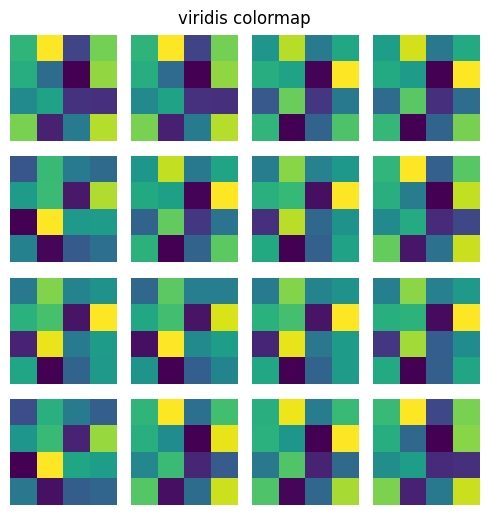

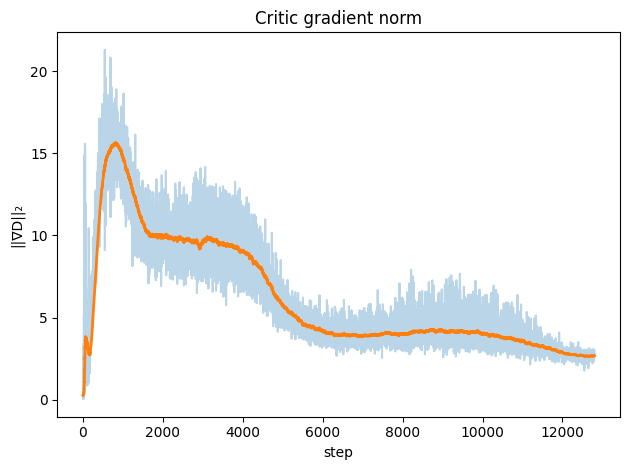

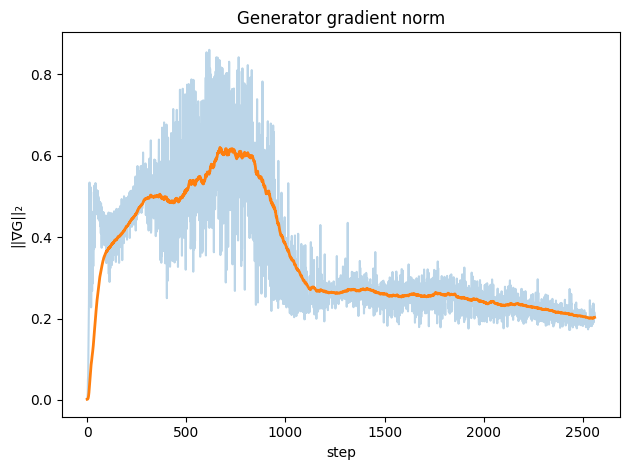

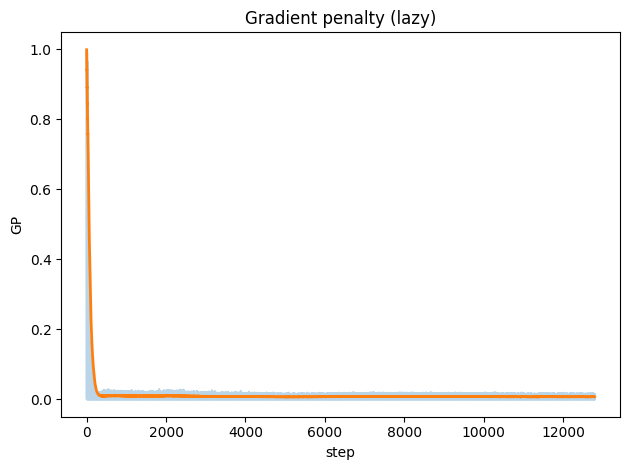

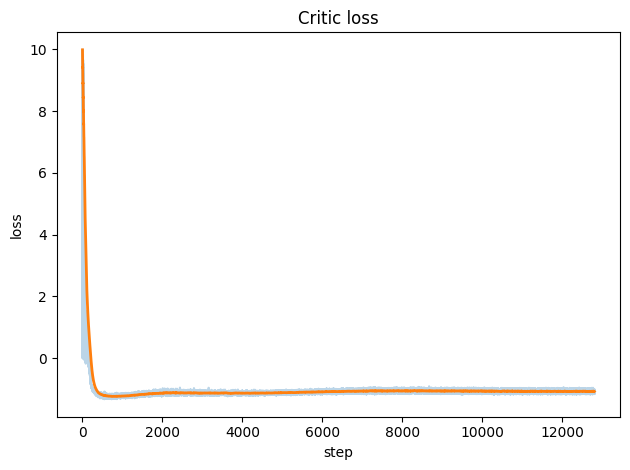

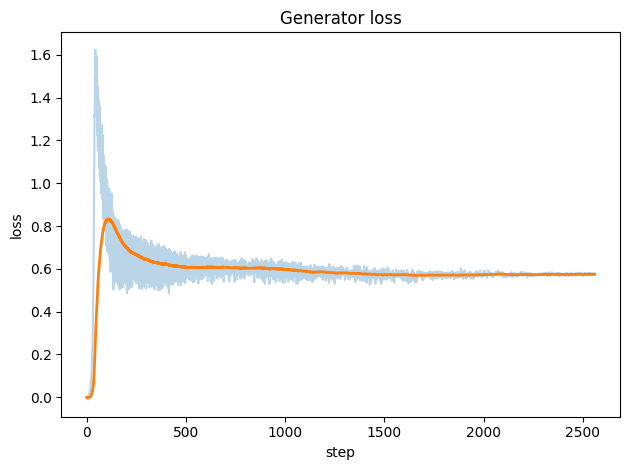

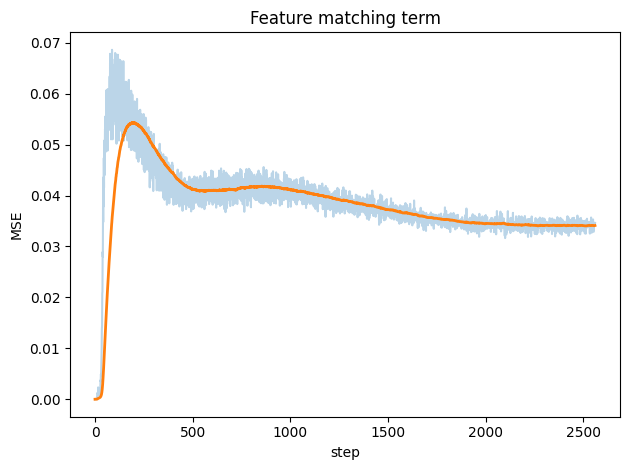

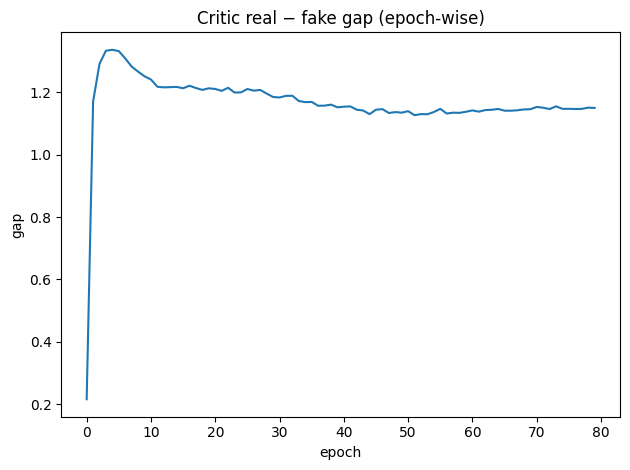

In [ ]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

IMG_SIZE   = 4        # 4x4 output
CHANNELS   = 1        # train single-channel; colorize only when plotting
BATCH_SIZE = 128

# model
Z_DIM       = 64
N_QUBITS    = 6
VQC_DEPTH   = 2
Q_FEAT_DIM  = N_QUBITS
UPSAMPLE_H  = 64

# WGAN-GP / train
N_CRITIC           = 5
GP_LAMBDA          = 10.0
GP_EVERY           = 2         # lazy GP: compute every k critic steps
LR_D               = 4e-4      # slightly faster critic (TTUR)
LR_G               = 1e-4
BETAS              = (0.0, 0.9)
EPOCHS             = 80
EMA_DECAY          = 0.999

# regularizers / auxiliaries
USE_FEATURE_MATCH  = True      # small feature-matching term to reduce collapse
FM_WEIGHT          = 5e-3
DRIFT_PENALTY      = 1e-3      # small L2 on critic outputs (stabilizer)

# energy head controls
NON_NEGATIVE_OUT   = True      # softplus head ensures non-negativity
ENFORCE_SUM        = False     # if True, normalize per-image to TARGET_SUM
TARGET_SUM         = 1.0

# symmetry & shots
USE_SYM_AUG        = True      # random rotations/flips on 4x4
TRAIN_WITH_SHOTS   = False     # use finite shots for QNode during train
SHOTS_TRAIN        = 2048
SHOTS_EVAL         = None      # analytic expectation at eval (None)

# runtime
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRY_LIGHTNING = True  # use lightning.qubit if available
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def _pick_device(shots=None):
    if TRY_LIGHTNING:
        try:
            return qml.device("lightning.qubit", wires=N_QUBITS, shots=shots)
        except Exception:
            pass
    return qml.device("default.qubit", wires=N_QUBITS, shots=shots)

ql_dev_train = _pick_device(SHOTS_TRAIN if TRAIN_WITH_SHOTS else None)
ql_dev_eval  = _pick_device(SHOTS_EVAL)

def vqc_template(inputs, weights):
    # data re-uploading + entanglement
    for i in range(N_QUBITS):
        qml.RX(inputs[i], wires=i)
        qml.RY(inputs[i], wires=i)
    for l in range(VQC_DEPTH):
        for i in range(N_QUBITS):
            qml.RZ(weights[l, i, 0], wires=i)
            qml.RX(weights[l, i, 1], wires=i)
            qml.RY(weights[l, i, 2], wires=i)
        # ring entanglement (CZ)
        for i in range(N_QUBITS):
            qml.CZ(wires=[i, (i + 1) % N_QUBITS])
def _best_diff_method(device) -> str:
    name = getattr(device, "short_name", str(device))
    has_shots = device.shots is not None
    if has_shots:
        return "parameter-shift"
    if "lightning.qubit" in name:
        return "adjoint"
    if "default.qubit" in name:
        return "backprop"
    return "parameter-shift"


def make_vqc_torchlayer(device):
    diff = _best_diff_method(device)
    @qml.qnode(device, interface="torch", diff_method=diff)
    def _qnode(inputs, weights):
        vqc_template(inputs, weights)
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    return TorchLayer(_qnode, {"weights": (VQC_DEPTH, N_QUBITS, 3)})

VQCLayerTrain = make_vqc_torchlayer(ql_dev_train)
VQCLayerEval  = make_vqc_torchlayer(ql_dev_eval)

class GenHybridVQC(nn.Module):
    """
    z (Z_DIM) -> MLP -> N_QUBITS -> VQC -> MLP -> image (1,4,4)
    """
    def __init__(self, z_dim=Z_DIM, img_size=IMG_SIZE, channels=CHANNELS):
        super().__init__()
        assert img_size == 4, "This tiny generator is designed for 4x4 output."
        self.img_size  = img_size
        self.channels  = channels
        self.fc_in = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, N_QUBITS)
        )
        self.vqc_train = VQCLayerTrain
        self.vqc_eval  = VQCLayerEval
        self.fc_out = nn.Sequential(
            nn.Linear(Q_FEAT_DIM, UPSAMPLE_H),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(UPSAMPLE_H, channels * img_size * img_size)
        )
        self.softplus = nn.Softplus()
        self.tanh     = nn.Tanh()

    def _call_vqc(self, h, training: bool):
        vqc = self.vqc_train if training else self.vqc_eval
        try:
            from torch.func import vmap
            q = vmap(lambda xi: vqc(xi))(h)           # (B, Q_FEAT_DIM)
        except Exception:
            q = torch.stack([vqc(xi) for xi in h], 0) # (B, Q_FEAT_DIM)
        return q

    def forward(self, z, non_negative=NON_NEGATIVE_OUT, enforce_sum=ENFORCE_SUM,
                target_sum: Optional[float]=TARGET_SUM, training: bool=True):
        h = self.fc_in(z)  # (B, N_QUBITS)
        q = self._call_vqc(h, training=training)
        y = self.fc_out(q).view(z.size(0), self.channels, self.img_size, self.img_size)
        if non_negative:
            y = self.softplus(y)
            if enforce_sum and (target_sum is not None):
                s = y.flatten(1).sum(dim=1, keepdim=True).clamp_min(1e-6)
                y = y / s.view(-1,1,1,1) * float(target_sum)
        else:
            y = self.tanh(y)  # [-1,1] legacy path
        return y

class CriticCNN(nn.Module):
    """
    WGAN critic for 4x4 grayscale: small conv stack -> scalar score
    Also exposes a feature() head for feature-matching.
    """
    def __init__(self, img_size=IMG_SIZE, channels=CHANNELS):
        super().__init__()
        assert img_size == 4, "This critic is designed for 4x4 input."
        f = 64
        self.conv = nn.Sequential(
            nn.Conv2d(channels, f, 3, 1, 1),         # 4x4 -> 4x4
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(f, f, 3, 2, 1),                # 4x4 -> 2x2
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(f, f*2, 3, 2, 1),              # 2x2 -> 1x1
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.out = nn.Linear(f*2*1*1, 1)

    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        return self.out(h)

    def features(self, x):
        return self.conv(x).view(x.size(0), -1)

def gradient_penalty(critic, real, fake, device=DEVICE):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    inter = eps * real + (1 - eps) * fake
    inter.requires_grad_(True)
    score = critic(inter)
    grad = torch.autograd.grad(
        outputs=score,
        inputs=inter,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    grad = grad.view(B, -1)
    return ((grad.norm(2, dim=1) - 1.0) ** 2).mean()

def weights_init(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

def grad_norm(module):
    total = 0.0
    for p in module.parameters():
        if p.grad is not None:
            n = p.grad.detach().data.norm(2)
            total += float(n.item() ** 2)
    return total ** 0.5

def ema_update(ema, src, decay=EMA_DECAY):
    with torch.no_grad():
        for p_ema, p in zip(ema.parameters(), src.parameters()):
            p_ema.data.mul_(decay).add_(p.data, alpha=1.0 - decay)

@torch.no_grad()
def sym_augment(x):
    if not USE_SYM_AUG:
        return x
    # random rotations by k*90 and optional horizontal flip
    k = torch.randint(0, 4, (1,), device=x.device).item()
    if k: x = torch.rot90(x, k, dims=(2,3))
    if torch.rand((), device=x.device) < 0.5:
        x = torch.flip(x, dims=(3,))
    return x

def make_models():
    G = GenHybridVQC(Z_DIM, IMG_SIZE, CHANNELS).to(DEVICE)
    D = CriticCNN(IMG_SIZE, CHANNELS).to(DEVICE)
    G.apply(weights_init); D.apply(weights_init)
    return G, D

def build_loader_from_numpy(npy_path: str, batch_size=BATCH_SIZE):
    arr = np.load(npy_path)  # expected (N,4,4) or (N,1,4,4)
    x = np.asarray(arr, dtype=np.float32)
    if x.ndim == 3:               # (N,H,W) -> (N,1,H,W)
        x = x[:, None, :, :]
    if not NON_NEGATIVE_OUT:
        # normalize per-sample to [0,1] then map to [-1,1]
        mn = x.reshape(len(x), -1).min(axis=1, keepdims=True)
        mx = x.reshape(len(x), -1).max(axis=1, keepdims=True)
        norm = (x.reshape(len(x), -1) - mn) / (mx - mn + 1e-8)
        x = (norm.reshape(x.shape) * 2.0 - 1.0)
    tens = torch.tensor(x, dtype=torch.float32)
    ds = TensorDataset(tens)
    return DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

def train_wgan_gp(train_loader, epochs=EPOCHS, n_critic=N_CRITIC, gp_lambda=GP_LAMBDA, z_dim=Z_DIM,
                  ckpt_every: int = 5) -> Tuple[nn.Module, nn.Module, dict, nn.Module]:
    G, D = make_models()
    G_ema = copy.deepcopy(G).eval()
    opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=BETAS)
    opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=BETAS)

    sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=max(1, epochs))
    sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=max(1, epochs))

    log = {k: [] for k in ["g_norm_G","g_norm_D","gp","D_real","D_fake","d_loss","g_loss","gap","fm"]}
    ema_log = {k: None for k in log}

    step = 0
    for epoch in range(1, epochs + 1):
        for (x_real,) in train_loader:
            x_real = x_real.to(DEVICE)
            if USE_SYM_AUG:
                x_real = sym_augment(x_real)

            for t in range(n_critic):
                z = torch.randn(x_real.size(0), z_dim, device=DEVICE)
                with torch.no_grad():
                    x_fake = G(z, training=True)

                D_real = D(x_real).mean()
                D_fake = D(x_fake).mean()

                # lazy GP
                do_gp = (step % GP_EVERY == 0)
                gp_val = gradient_penalty(D, x_real, x_fake, DEVICE) if do_gp else torch.tensor(0.0, device=DEVICE)

                d_loss = -(D_real - D_fake) + gp_lambda * gp_val + DRIFT_PENALTY * (D_real.pow(2) + D_fake.pow(2))

                opt_D.zero_grad(set_to_none=True)
                d_loss.backward()
                log["g_norm_D"].append(grad_norm(D))
                log["gp"].append(float(gp_val.item()))
                log["D_real"].append(float(D_real.item()))
                log["D_fake"].append(float(D_fake.item()))
                log["d_loss"].append(float(d_loss.item()))
                opt_D.step()
                step += 1

            z = torch.randn(x_real.size(0), z_dim, device=DEVICE)
            x_fake = G(z, training=True)
            g_adv = -D(x_fake).mean()

            g_loss = g_adv
            fm_term = torch.tensor(0.0, device=DEVICE)
            if USE_FEATURE_MATCH:
                with torch.no_grad():
                    f_real = D.features(x_real)
                f_fake = D.features(x_fake)
                fm_term = (f_fake.mean(dim=0) - f_real.mean(dim=0)).pow(2).mean()
                g_loss = g_loss + FM_WEIGHT * fm_term

            opt_G.zero_grad(set_to_none=True)
            g_loss.backward()
            log["g_norm_G"].append(grad_norm(G))
            log["g_loss"].append(float(g_loss.item()))
            log["fm"].append(float(fm_term.item()))
            opt_G.step()

            ema_update(G_ema, G, decay=EMA_DECAY)

            if step % 100 == 0:
                gap = (np.array(log["D_real"][-n_critic:]).mean() - np.array(log["D_fake"][-n_critic:]).mean()) if len(log["D_real"])>=n_critic else 0.0
                print(f"[epoch {epoch:03d} | step {step:06d}] D(real)={D_real.item():.3f} D(fake)={D_fake.item():.3f} "
                      f"gp={gp_val.item():.3f} d_loss={d_loss.item():.3f} g_loss={g_loss.item():.3f} gap~{gap:.3f}")

        sched_D.step(); sched_G.step()

        if (epoch % max(1, ckpt_every)) == 0:
            ckpt_path = CHECKPOINT_DIR / f"qgan_epoch_{epoch:03d}.pt"
            torch.save({
                "G": G.state_dict(), "D": D.state_dict(), "G_ema": G_ema.state_dict(),
                "opt_G": opt_G.state_dict(), "opt_D": opt_D.state_dict(),
                "epoch": epoch, "log": log
            }, ckpt_path)

        if len(log["D_real"])>0 and len(log["D_fake"])>0:
            log["gap"].append(np.mean(log["D_real"][-len(train_loader):]) - np.mean(log["D_fake"][-len(train_loader):]))
        else:
            log["gap"].append(0.0)

    return G, D, log, G_ema

@torch.no_grad()
def sample_from_generator(G, z_dim=Z_DIM, n_samples=16, device=None, training: bool=False):
    device = device or next(G.parameters()).device
    G.eval()
    z = torch.randn(n_samples, z_dim, device=device)
    x = G(z, training=training)  # shape (N,1,4,4), non-negative if NON_NEGATIVE_OUT
    if not NON_NEGATIVE_OUT:
        x = (x + 1) / 2.0  # map to [0,1] for display if tanh path
    else:
        B = x.size(0)
        x_ = x.view(B, -1)
        mn = x_.min(dim=1, keepdim=True).values
        mx = x_.max(dim=1, keepdim=True).values
        x = ((x_ - mn) / (mx - mn + 1e-8)).view_as(x)
    return x

@torch.no_grad()
def save_generator_grid_gray(G, path="jets_qgan_grid_4x4_gray.png", n_samples=16, nrow=4, pad_value=1.0):
    imgs = sample_from_generator(G, Z_DIM, n_samples=n_samples)
    grid = make_grid(imgs, nrow=nrow, padding=2, pad_value=pad_value)  # [0,1]
    save_image(grid, path)
    print(f"Saved {n_samples} grayscale samples to {path}")
    return imgs, grid

def plot_series(y, title, ylabel, xlabel="step", smooth=0.98):
    if len(y)==0: return
    # EMA smoothing for readability
    sm = []
    m = y[0]
    for v in y:
        m = smooth*m + (1-smooth)*v
        sm.append(m)
    plt.figure()
    plt.plot(y, alpha=0.3)
    plt.plot(sm, linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_training_logs(logs):
    plot_series(logs["g_norm_D"], "Critic gradient norm", "||∇D||₂")
    plot_series(logs["g_norm_G"], "Generator gradient norm", "||∇G||₂")
    plot_series(logs["gp"],       "Gradient penalty (lazy)",  "GP")
    plot_series(logs["d_loss"],   "Critic loss",             "loss")
    plot_series(logs["g_loss"],   "Generator loss",          "loss")
    plot_series(logs["fm"],       "Feature matching term",   "MSE")
    gap = np.array(logs.get("gap", []), dtype=np.float32)
    if len(gap):
        plt.figure(); plt.plot(gap); plt.title("Critic real − fake gap (epoch-wise)"); plt.ylabel("gap"); plt.xlabel("epoch"); plt.tight_layout(); plt.show()

@torch.no_grad()
def show_generator_samples_viridis(G, z_dim=Z_DIM, n=16, device=None, rows=4, cols=4,
                                   force_sparse_view=False, topk=None, thr=None, training: bool=False):
    device = device or next(G.parameters()).device
    G.eval()
    x = sample_from_generator(G, z_dim, n_samples=n, device=device, training=training)  # [0,1]
    imgs = x[:,0].clamp(0,1).cpu().numpy()  # (N,H,W)

    if force_sparse_view:
        for i in range(imgs.shape[0]):
            if topk is not None and topk > 0:
                flat = imgs[i].ravel()
                k = min(topk, flat.size)
                t = np.partition(flat, -k)[-k]
                m = imgs[i] >= t
                tmp = np.zeros_like(imgs[i]); tmp[m] = imgs[i][m]
                imgs[i] = tmp
            elif thr is not None:
                m = imgs[i] >= float(thr)
                tmp = np.zeros_like(imgs[i]); tmp[m] = imgs[i][m]
                imgs[i] = tmp

    rows = rows or int(np.ceil(np.sqrt(n))); cols = cols or int(np.ceil(n/rows))
    fig, axs = plt.subplots(rows, cols, figsize=(5,5))
    axs = np.atleast_2d(axs).flatten()
    for ax, img in zip(axs, imgs):
        ax.imshow(img, cmap="viridis", interpolation="nearest", origin="lower", vmin=0.0, vmax=1.0)
        ax.axis("off")
    for ax in axs[len(imgs):]:
        ax.axis("off")
    plt.tight_layout()
    plt.suptitle("viridis colormap", y=1.02)
    plt.show()
    return imgs

train_loader = build_loader_from_numpy("hep_train_images.npy", batch_size=BATCH_SIZE)

G, D, logs, G_ema = train_wgan_gp(train_loader)

_, grid = save_generator_grid_gray(G_ema, path="jets_qgan_grid_4x4_gray.png", n_samples=16, nrow=4)
_ = show_generator_samples_viridis(G_ema, Z_DIM, n=16, device=DEVICE)
plot_training_logs(logs)

[epoch 001 | step 000100] D(real)=-1.193 D(fake)=-2.185 gp=0.000 d_loss=-0.986 g_loss=2.475 gap~0.969 ms=0.002
[epoch 002 | step 000200] D(real)=-0.128 D(fake)=-1.192 gp=0.000 d_loss=-1.063 g_loss=1.526 gap~1.072 ms=0.002
[epoch 002 | step 000300] D(real)=0.253 D(fake)=-0.865 gp=0.000 d_loss=-1.117 g_loss=1.147 gap~1.118 ms=0.002
[epoch 003 | step 000400] D(real)=0.576 D(fake)=-0.479 gp=0.000 d_loss=-1.054 g_loss=0.805 gap~1.098 ms=0.002
[epoch 004 | step 000500] D(real)=0.670 D(fake)=-0.361 gp=0.000 d_loss=-1.031 g_loss=0.640 gap~1.057 ms=0.002
[epoch 004 | step 000600] D(real)=0.803 D(fake)=-0.271 gp=0.000 d_loss=-1.073 g_loss=0.537 gap~1.110 ms=0.002
[epoch 005 | step 000700] D(real)=0.678 D(fake)=-0.394 gp=0.000 d_loss=-1.072 g_loss=0.607 gap~1.096 ms=0.002
[epoch 005 | step 000800] D(real)=0.669 D(fake)=-0.370 gp=0.000 d_loss=-1.039 g_loss=0.560 gap~1.054 ms=0.002
[epoch 006 | step 000900] D(real)=0.632 D(fake)=-0.396 gp=0.000 d_loss=-1.027 g_loss=0.567 gap~1.062 ms=0.002
[epoch 0

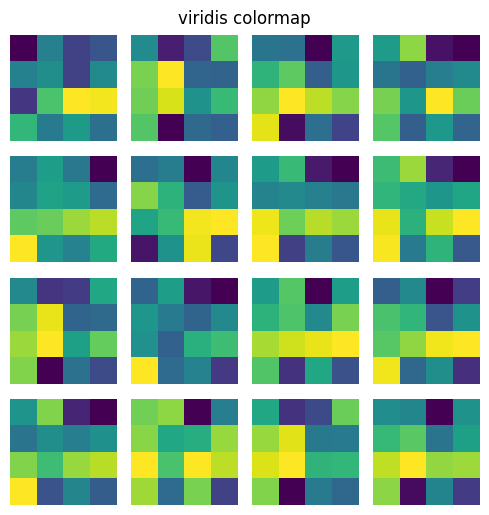

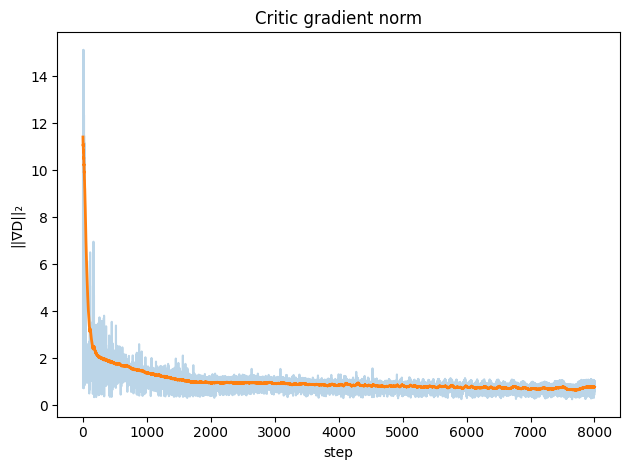

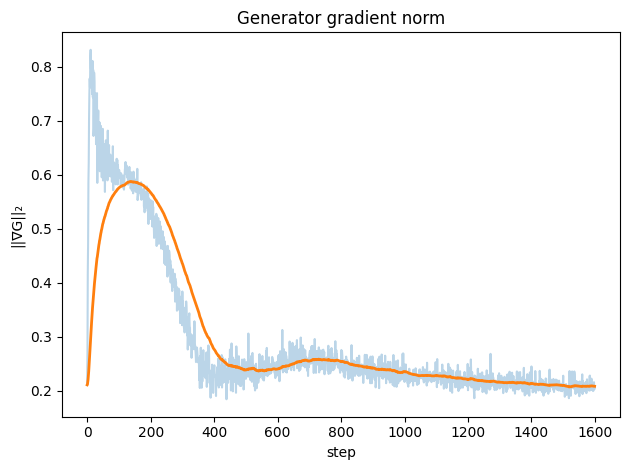

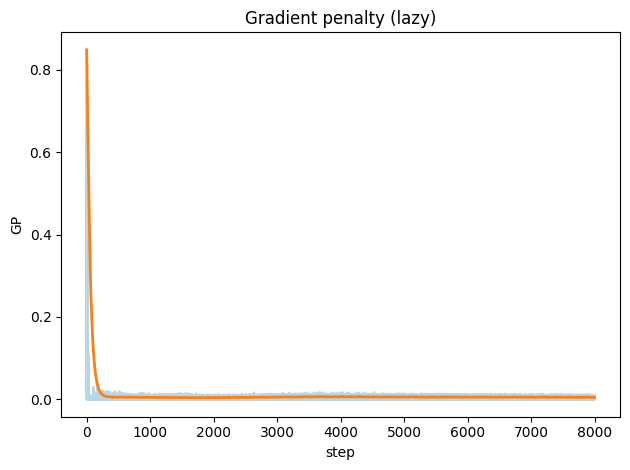

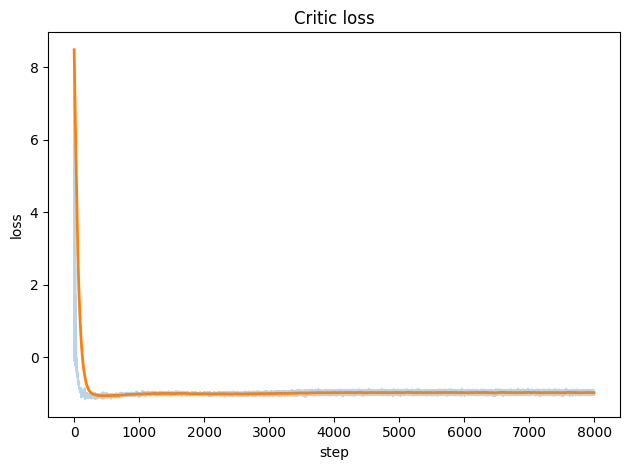

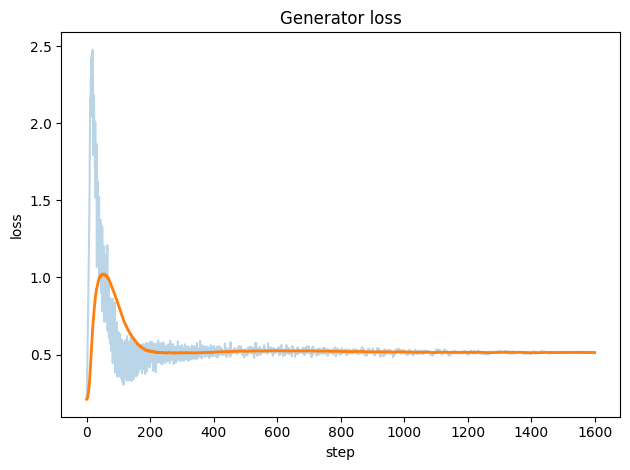

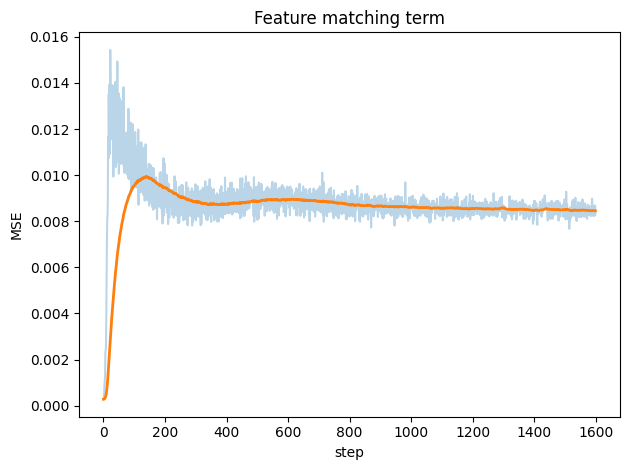

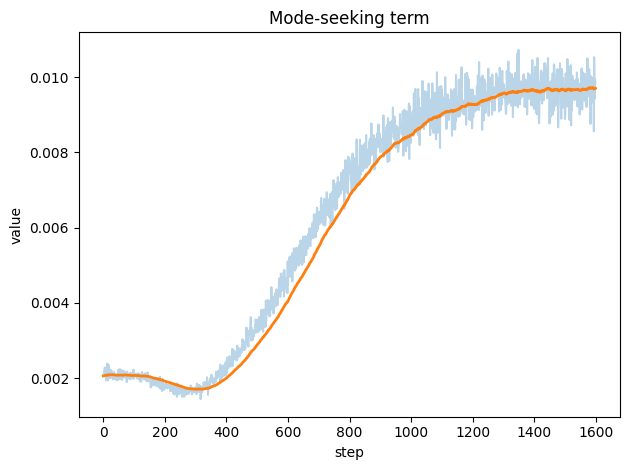

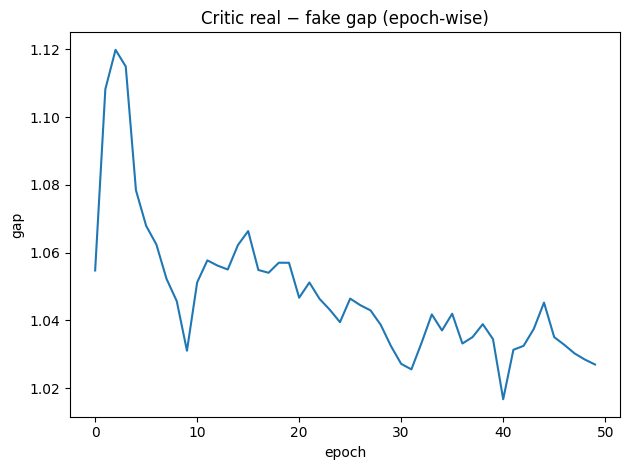

In [ ]:
#fix mode collapse
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# data
IMG_SIZE   = 4        # 4x4 output
CHANNELS   = 1        # train single-channel; colorize only when plotting
BATCH_SIZE = 128

# model
Z_DIM       = 64
N_QUBITS    = 6
VQC_DEPTH   = 2
Q_FEAT_DIM  = N_QUBITS
UPSAMPLE_H  = 64

# WGAN-GP / train
N_CRITIC           = 5
GP_LAMBDA          = 10.0
GP_EVERY           = 2         # lazy GP: compute every k critic steps
LR_D               = 4e-4      # slightly faster critic (TTUR)
LR_G               = 1e-4
BETAS              = (0.0, 0.9)
EPOCHS             = 50
EMA_DECAY          = 0.999

# regularizers / auxiliaries
USE_FEATURE_MATCH  = True      # small feature-matching term to reduce collapse
FM_WEIGHT          = 5e-3
DRIFT_PENALTY      = 1e-3      # small L2 on critic outputs (stabilizer)

# anti-collapse toggles
USE_SPECTRAL_NORM  = True
USE_MINIBATCH_STD  = True
USE_MODE_SEEKING   = True
MS_WEIGHT          = 0.15      # mode-seeking weight
USE_INSTANCE_NOISE = True
IN_NOISE_INIT      = 0.08      # initial sigma
IN_NOISE_DECAY     = 0.9995    # per-step decay
IN_NOISE_MIN       = 0.001

# energy head controls
NON_NEGATIVE_OUT   = True      # softplus head ensures non-negativity
ENFORCE_SUM        = False     # if True, normalize per-image to TARGET_SUM
TARGET_SUM         = 1.0

# symmetry & shots
USE_SYM_AUG        = True      # random rotations/flips on 4x4
TRAIN_WITH_SHOTS   = False     # use finite shots for QNode during train
SHOTS_TRAIN        = 2048
SHOTS_EVAL         = None      # analytic expectation at eval (None)

# runtime
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRY_LIGHTNING = True  # use lightning.qubit if available
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def _pick_device(shots=None):
    if TRY_LIGHTNING:
        try:
            return qml.device("lightning.qubit", wires=N_QUBITS, shots=shots)
        except Exception:
            pass
    return qml.device("default.qubit", wires=N_QUBITS, shots=shots)

ql_dev_train = _pick_device(SHOTS_TRAIN if TRAIN_WITH_SHOTS else None)
ql_dev_eval  = _pick_device(SHOTS_EVAL)

def vqc_template(inputs, weights):
    # data re-uploading + entanglement
    for i in range(N_QUBITS):
        qml.RX(inputs[i], wires=i)
        qml.RY(inputs[i], wires=i)
    for l in range(VQC_DEPTH):
        for i in range(N_QUBITS):
            qml.RZ(weights[l, i, 0], wires=i)
            qml.RX(weights[l, i, 1], wires=i)
            qml.RY(weights[l, i, 2], wires=i)
        # ring entanglement (CZ)
        for i in range(N_QUBITS):
            qml.CZ(wires=[i, (i + 1) % N_QUBITS])

def _best_diff_method(device) -> str:
    name = getattr(device, "short_name", str(device))
    has_shots = device.shots is not None
    if has_shots:
        return "parameter-shift"
    if "lightning.qubit" in name:
        return "adjoint"
    if "default.qubit" in name:
        return "backprop"
    return "parameter-shift"

def make_vqc_torchlayer(device):
    diff = _best_diff_method(device)
    @qml.qnode(device, interface="torch", diff_method=diff)
    def _qnode(inputs, weights):
        vqc_template(inputs, weights)
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    return TorchLayer(_qnode, {"weights": (VQC_DEPTH, N_QUBITS, 3)})

VQCLayerTrain = make_vqc_torchlayer(ql_dev_train)
VQCLayerEval  = make_vqc_torchlayer(ql_dev_eval)

def gradient_penalty(critic, real, fake, device=DEVICE):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    inter = eps * real + (1 - eps) * fake
    inter.requires_grad_(True)
    score = critic(inter)
    grad = torch.autograd.grad(
        outputs=score,
        inputs=inter,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    grad = grad.view(B, -1)
    return ((grad.norm(2, dim=1) - 1.0) ** 2).mean()

def weights_init(m):
    # orthogonal tends to work nicely with spectral norm; fallback to normal for non-2D params
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        try:
            nn.init.orthogonal_(m.weight)
        except Exception:
            nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

def grad_norm(module):
    total = 0.0
    for p in module.parameters():
        if p.grad is not None:
            n = p.grad.detach().data.norm(2)
            total += float(n.item() ** 2)
    return total ** 0.5

def ema_update(ema, src, decay=EMA_DECAY):
    with torch.no_grad():
        for p_ema, p in zip(ema.parameters(), src.parameters()):
            p_ema.data.mul_(decay).add_(p.data, alpha=1.0 - decay)

@torch.no_grad()
def sym_augment(x):
    if not USE_SYM_AUG:
        return x
    k = torch.randint(0, 4, (1,), device=x.device).item()
    if k: x = torch.rot90(x, k, dims=(2,3))
    if torch.rand((), device=x.device) < 0.5:
        x = torch.flip(x, dims=(3,))
    return x

def add_instance_noise(x, step):
    if not USE_INSTANCE_NOISE:
        return x
    sigma = max(IN_NOISE_MIN, IN_NOISE_INIT * (IN_NOISE_DECAY ** step))
    if sigma <= 0.0:
        return x
    return x + torch.randn_like(x) * sigma

def minibatch_stddev(x, group_size=16, eps=1e-8):
    # x: (B, C, H, W). Append a 1-channel map of per-group stddev
    if not USE_MINIBATCH_STD:
        return x
    B, C, H, W = x.shape
    g = min(group_size, B)
    if B % g != 0:
        g = math.gcd(B, g)  # fallback: use gcd to avoid remainder
        if g == 0:  # should not happen
            return x
    y = x.view(g, B // g, C, H, W)         # (G, M, C, H, W)
    y = y - y.mean(dim=1, keepdim=True)     # (G, M, C, H, W)
    y = torch.sqrt((y ** 2).mean(dim=1) + eps)  # (G, C, H, W)
    y = y.mean(dim=(1,2,3), keepdim=True)       # (G, 1, 1, 1)
    y = y.repeat(B // g, 1, H, W)               # (M, 1, H, W)
    y = y.view(B, 1, H, W)
    return torch.cat([x, y], dim=1)             # (B, C+1, H, W)

class GenHybridVQC(nn.Module):
    def __init__(self, z_dim=Z_DIM, img_size=IMG_SIZE, channels=CHANNELS):
        super().__init__()
        assert img_size == 4, "This tiny generator is designed for 4x4 output."
        self.img_size  = img_size
        self.channels  = channels
        self.fc_in = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, N_QUBITS)
        )
        self.vqc_train = VQCLayerTrain
        self.vqc_eval  = VQCLayerEval
        self.fc_out = nn.Sequential(
            nn.Linear(Q_FEAT_DIM, UPSAMPLE_H),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(UPSAMPLE_H, channels * img_size * img_size)
        )
        self.softplus = nn.Softplus()
        self.tanh     = nn.Tanh()

    def _call_vqc(self, h, training: bool):
        vqc = self.vqc_train if training else self.vqc_eval
        try:
            from torch.func import vmap
            q = vmap(lambda xi: vqc(xi))(h)           # (B, Q_FEAT_DIM)
        except Exception:
            q = torch.stack([vqc(xi) for xi in h], 0) # (B, Q_FEAT_DIM)
        return q

    def forward(self, z, non_negative=NON_NEGATIVE_OUT, enforce_sum=ENFORCE_SUM,
                target_sum: Optional[float]=TARGET_SUM, training: bool=True):
        h = self.fc_in(z)  # (B, N_QUBITS)
        q = self._call_vqc(h, training=training)
        y = self.fc_out(q).view(z.size(0), self.channels, self.img_size, self.img_size)
        if non_negative:
            y = self.softplus(y)
            if enforce_sum and (target_sum is not None):
                s = y.flatten(1).sum(dim=1, keepdim=True).clamp_min(1e-6)
                y = y / s.view(-1,1,1,1) * float(target_sum)
        else:
            y = self.tanh(y)  # [-1,1] legacy path
        return y

class CriticCNN(nn.Module):
    def __init__(self, img_size=IMG_SIZE, channels=CHANNELS):
        super().__init__()
        assert img_size == 4, "This critic is designed for 4x4 input."
        f = 64

        def sn(module):
            return nn.utils.spectral_norm(module) if USE_SPECTRAL_NORM else module

        # First convs
        self.conv1 = nn.Sequential(
            sn(nn.Conv2d(channels, f, 3, 1, 1)),      # 4x4 -> 4x4
            nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(f, f, 3, 2, 1)),             # 4x4 -> 2x2
            nn.LeakyReLU(0.2, inplace=True),
        )
        in_ch2 = f + (1 if USE_MINIBATCH_STD else 0)
        self.conv2 = nn.Sequential(
            sn(nn.Conv2d(in_ch2, f*2, 3, 2, 1)),      # 2x2 -> 1x1
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.out = sn(nn.Linear(f*2*1*1, 1))

    def forward(self, x):
        h = self.conv1(x)
        h = minibatch_stddev(h)   # append stddev channel if enabled
        h = self.conv2(h).view(x.size(0), -1)
        return self.out(h)

    def features(self, x):
        h = self.conv1(x)
        h = minibatch_stddev(h)
        return self.conv2(h).view(x.size(0), -1)

def make_models():
    G = GenHybridVQC(Z_DIM, IMG_SIZE, CHANNELS).to(DEVICE)
    D = CriticCNN(IMG_SIZE, CHANNELS).to(DEVICE)
    G.apply(weights_init); D.apply(weights_init)
    return G, D

def build_loader_from_numpy(npy_path: str, batch_size=BATCH_SIZE):
    arr = np.load(npy_path)  # expected (N,4,4) or (N,1,4,4)
    x = np.asarray(arr, dtype=np.float32)
    if x.ndim == 3:               # (N,H,W) -> (N,1,H,W)
        x = x[:, None, :, :]
    if not NON_NEGATIVE_OUT:
        mn = x.reshape(len(x), -1).min(axis=1, keepdims=True)
        mx = x.reshape(len(x), -1).max(axis=1, keepdims=True)
        norm = (x.reshape(len(x), -1) - mn) / (mx - mn + 1e-8)
        x = (norm.reshape(x.shape) * 2.0 - 1.0)
    tens = torch.tensor(x, dtype=torch.float32)
    ds = TensorDataset(tens)
    return DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

def train_wgan_gp(train_loader, epochs=EPOCHS, n_critic=N_CRITIC, gp_lambda=GP_LAMBDA, z_dim=Z_DIM,
                  ckpt_every: int = 5) -> Tuple[nn.Module, nn.Module, dict, nn.Module]:
    G, D = make_models()
    G_ema = copy.deepcopy(G).eval()
    opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=BETAS)
    opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=BETAS)

    # optional schedulers
    sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=max(1, epochs))
    sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=max(1, epochs))

    # logs
    log = {k: [] for k in ["g_norm_G","g_norm_D","gp","D_real","D_fake","d_loss","g_loss","gap","fm","ms"]}
    step = 0

    for epoch in range(1, epochs + 1):
        for (x_real,) in train_loader:
            x_real = x_real.to(DEVICE)
            if USE_SYM_AUG:
                x_real = sym_augment(x_real)

            for t in range(n_critic):
                z = torch.randn(x_real.size(0), z_dim, device=DEVICE)
                with torch.no_grad():
                    x_fake = G(z, training=True)

                # Instance noise on both real/fake to keep supports overlapped
                x_r = add_instance_noise(x_real, step)
                x_f = add_instance_noise(x_fake, step)

                D_real = D(x_r).mean()
                D_fake = D(x_f).mean()

                do_gp = (step % GP_EVERY == 0)
                gp_val = gradient_penalty(D, x_r, x_f, DEVICE) if do_gp else torch.tensor(0.0, device=DEVICE)

                d_loss = -(D_real - D_fake) + gp_lambda * gp_val + DRIFT_PENALTY * (D_real.pow(2) + D_fake.pow(2))

                opt_D.zero_grad(set_to_none=True)
                d_loss.backward()
                log["g_norm_D"].append(grad_norm(D))
                log["gp"].append(float(gp_val.item()))
                log["D_real"].append(float(D_real.item()))
                log["D_fake"].append(float(D_fake.item()))
                log["d_loss"].append(float(d_loss.item()))
                opt_D.step()
                step += 1

            z = torch.randn(x_real.size(0), z_dim, device=DEVICE)
            x_fake = G(z, training=True)
            g_adv = -D(add_instance_noise(x_fake, step)).mean()

            g_loss = g_adv
            fm_term = torch.tensor(0.0, device=DEVICE)
            ms_term = torch.tensor(0.0, device=DEVICE)

            if USE_FEATURE_MATCH:
                with torch.no_grad():
                    f_real = D.features(add_instance_noise(x_real, step))
                f_fake = D.features(add_instance_noise(x_fake, step))
                fm_term = (f_fake.mean(dim=0) - f_real.mean(dim=0)).pow(2).mean()
                g_loss = g_loss + FM_WEIGHT * fm_term

            if USE_MODE_SEEKING:
                # sample a second latent batch and encourage output diversity
                z2 = torch.randn_like(z)
                x1 = G(z,  training=True)
                x2 = G(z2, training=True)
                # L_ms = mean( |x1 - x2|_1 / (||z1 - z2||_2 + eps) )
                num = (x1 - x2).abs().flatten(1).mean(dim=1)
                den = (z - z2).norm(p=2, dim=1) + 1e-8
                ms_term = (num / den).mean()
                # maximize ms_term => minimize with negative sign
                g_loss = g_loss - MS_WEIGHT * ms_term

            opt_G.zero_grad(set_to_none=True)
            g_loss.backward()
            log["g_norm_G"].append(grad_norm(G))
            log["g_loss"].append(float(g_loss.item()))
            log["fm"].append(float(fm_term.item()))
            log["ms"].append(float(ms_term.item()))
            opt_G.step()

            # EMA update
            ema_update(G_ema, G, decay=EMA_DECAY)

            if step % 100 == 0:
                gap = (np.array(log["D_real"][-n_critic:]).mean() - np.array(log["D_fake"][-n_critic:]).mean()) if len(log["D_real"])>=n_critic else 0.0
                print(f"[epoch {epoch:03d} | step {step:06d}] D(real)={D_real.item():.3f} D(fake)={D_fake.item():.3f} "
                      f"gp={gp_val.item():.3f} d_loss={d_loss.item():.3f} g_loss={g_loss.item():.3f} gap~{gap:.3f} ms={float(ms_term.item()):.3f}")

        # schedulers per epoch
        sched_D.step(); sched_G.step()

        if (epoch % max(1, ckpt_every)) == 0:
            ckpt_path = CHECKPOINT_DIR / f"qgan_epoch_{epoch:03d}.pt"
            torch.save({
                "G": G.state_dict(), "D": D.state_dict(), "G_ema": G_ema.state_dict(),
                "opt_G": opt_G.state_dict(), "opt_D": opt_D.state_dict(),
                "epoch": epoch, "log": log
            }, ckpt_path)

        if len(log["D_real"])>0 and len(log["D_fake"])>0:
            log["gap"].append(np.mean(log["D_real"][-len(train_loader):]) - np.mean(log["D_fake"][-len(train_loader):]))
        else:
            log["gap"].append(0.0)

    return G, D, log, G_ema

@torch.no_grad()
def sample_from_generator(G, z_dim=Z_DIM, n_samples=16, device=None, training: bool=False):
    device = device or next(G.parameters()).device
    G.eval()
    z = torch.randn(n_samples, z_dim, device=device)
    x = G(z, training=training)  # shape (N,1,4,4), non-negative if NON_NEGATIVE_OUT
    if not NON_NEGATIVE_OUT:
        x = (x + 1) / 2.0  # map to [0,1] for display if tanh path
    else:
        B = x.size(0)
        x_ = x.view(B, -1)
        mn = x_.min(dim=1, keepdim=True).values
        mx = x_.max(dim=1, keepdim=True).values
        x = ((x_ - mn) / (mx - mn + 1e-8)).view_as(x)
    return x

@torch.no_grad()
def save_generator_grid_gray(G, path="jets_qgan_grid_4x4_gray.png", n_samples=16, nrow=4, pad_value=1.0):
    imgs = sample_from_generator(G, Z_DIM, n_samples=n_samples)
    grid = make_grid(imgs, nrow=nrow, padding=2, pad_value=pad_value)  # [0,1]
    save_image(grid, path)
    print(f"Saved {n_samples} grayscale samples to {path}")
    return imgs, grid

def plot_series(y, title, ylabel, xlabel="step", smooth=0.98):
    if len(y)==0: return
    sm = []
    m = y[0]
    for v in y:
        m = smooth*m + (1-smooth)*v
        sm.append(m)
    plt.figure()
    plt.plot(y, alpha=0.3)
    plt.plot(sm, linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_training_logs(logs):
    plot_series(logs["g_norm_D"], "Critic gradient norm", "||∇D||₂")
    plot_series(logs["g_norm_G"], "Generator gradient norm", "||∇G||₂")
    plot_series(logs["gp"],       "Gradient penalty (lazy)",  "GP")
    plot_series(logs["d_loss"],   "Critic loss",             "loss")
    plot_series(logs["g_loss"],   "Generator loss",          "loss")
    plot_series(logs["fm"],       "Feature matching term",   "MSE")
    plot_series(logs["ms"],       "Mode-seeking term",       "value")
    gap = np.array(logs.get("gap", []), dtype=np.float32)
    if len(gap):
        plt.figure(); plt.plot(gap); plt.title("Critic real − fake gap (epoch-wise)"); plt.ylabel("gap"); plt.xlabel("epoch"); plt.tight_layout(); plt.show()

@torch.no_grad()
def show_generator_samples_viridis(G, z_dim=Z_DIM, n=16, device=None, rows=4, cols=4,
                                   force_sparse_view=False, topk=None, thr=None, training: bool=False):
    device = device or next(G.parameters()).device
    G.eval()
    x = sample_from_generator(G, z_dim, n_samples=n, device=device, training=training)  # [0,1]
    imgs = x[:,0].clamp(0,1).cpu().numpy()  # (N,H,W)

    if force_sparse_view:
        for i in range(imgs.shape[0]):
            if topk is not None and topk > 0:
                flat = imgs[i].ravel()
                k = min(topk, flat.size)
                t = np.partition(flat, -k)[-k]
                m = imgs[i] >= t
                tmp = np.zeros_like(imgs[i]); tmp[m] = imgs[i][m]
                imgs[i] = tmp
            elif thr is not None:
                m = imgs[i] >= float(thr)
                tmp = np.zeros_like(imgs[i]); tmp[m] = imgs[i][m]
                imgs[i] = tmp

    rows = rows or int(np.ceil(np.sqrt(n))); cols = cols or int(np.ceil(n/rows))
    fig, axs = plt.subplots(rows, cols, figsize=(5,5))
    axs = np.atleast_2d(axs).flatten()
    for ax, img in zip(axs, imgs):
        ax.imshow(img, cmap="viridis", interpolation="nearest", origin="lower", vmin=0.0, vmax=1.0)
        ax.axis("off")
    for ax in axs[len(imgs):]:
        ax.axis("off")
    plt.tight_layout()
    plt.suptitle("viridis colormap", y=1.02)
    plt.show()
    return imgs

train_loader = build_loader_from_numpy("hep_train_images.npy", batch_size=BATCH_SIZE)

G, D, logs, G_ema = train_wgan_gp(train_loader)

_, grid = save_generator_grid_gray(G_ema, path="jets_qgan_grid_4x4_gray.png", n_samples=16, nrow=4)
_ = show_generator_samples_viridis(G_ema, Z_DIM, n=16, device=DEVICE)
plot_training_logs(logs)

In [ ]:
# =========================================================
# Hybrid QGAN (WGAN-GP) for tiny 4x4 jet images — anti-collapse edition
# Changes vs your version:
#  - Critic: spectral normalization + minibatch-stddev channel
#  - G loss: adds mode-seeking regularizer to encourage diversity
#  - D input: decaying instance noise for better support overlap early on
#  - Kept: WGAN-GP (lazy), EMA for G, symmetry aug, feature matching
# =========================================================
import os, copy, math, random, warnings
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane.qnn import TorchLayer

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------ config ------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# data
IMG_SIZE   = 4        # 4x4 output
CHANNELS   = 1        # train single-channel; colorize only when plotting
BATCH_SIZE = 128

# model
Z_DIM       = 64
N_QUBITS    = 6
VQC_DEPTH   = 2
Q_FEAT_DIM  = N_QUBITS
UPSAMPLE_H  = 64

# WGAN-GP / train
N_CRITIC           = 5
GP_LAMBDA          = 10.0
GP_EVERY           = 2         # lazy GP: compute every k critic steps
LR_D               = 4e-4      # slightly faster critic (TTUR)
LR_G               = 1e-4
BETAS              = (0.0, 0.9)
EPOCHS             = 5
EMA_DECAY          = 0.999

# regularizers / auxiliaries
USE_FEATURE_MATCH  = True      # small feature-matching term to reduce collapse
FM_WEIGHT          = 5e-3
DRIFT_PENALTY      = 1e-3      # small L2 on critic outputs (stabilizer)

# anti-collapse toggles
USE_SPECTRAL_NORM  = True
USE_MINIBATCH_STD  = True
USE_MODE_SEEKING   = True
MS_WEIGHT          = 0.15      # mode-seeking weight
USE_INSTANCE_NOISE = True
IN_NOISE_INIT      = 0.08      # initial sigma
IN_NOISE_DECAY     = 0.9995    # per-step decay
IN_NOISE_MIN       = 0.001

# energy head controls
NON_NEGATIVE_OUT   = True      # softplus head ensures non-negativity
ENFORCE_SUM        = False     # if True, normalize per-image to TARGET_SUM
TARGET_SUM         = 1.0

# symmetry & shots
USE_SYM_AUG        = True      # random rotations/flips on 4x4
TRAIN_WITH_SHOTS   = False     # use finite shots for QNode during train
SHOTS_TRAIN        = 2048
SHOTS_EVAL         = None      # analytic expectation at eval (None)

# runtime
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRY_LIGHTNING = True  # use lightning.qubit if available
CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------ Pennylane device helpers ------------------
def _pick_device(shots=None):
    if TRY_LIGHTNING:
        try:
            return qml.device("lightning.qubit", wires=N_QUBITS, shots=shots)
        except Exception:
            pass
    return qml.device("default.qubit", wires=N_QUBITS, shots=shots)

# Build two devices (train/eval) so we can switch shots cleanly
ql_dev_train = _pick_device(SHOTS_TRAIN if TRAIN_WITH_SHOTS else None)
ql_dev_eval  = _pick_device(SHOTS_EVAL)

# ------------------ Quantum layer ------------------
def vqc_template(inputs, weights):
    # data re-uploading + entanglement
    for i in range(N_QUBITS):
        qml.RX(inputs[i], wires=i)
        qml.RY(inputs[i], wires=i)
    for l in range(VQC_DEPTH):
        for i in range(N_QUBITS):
            qml.RZ(weights[l, i, 0], wires=i)
            qml.RX(weights[l, i, 1], wires=i)
            qml.RY(weights[l, i, 2], wires=i)
        # ring entanglement (CZ)
        for i in range(N_QUBITS):
            qml.CZ(wires=[i, (i + 1) % N_QUBITS])

def _best_diff_method(device) -> str:
    name = getattr(device, "short_name", str(device))
    has_shots = device.shots is not None
    if has_shots:
        return "parameter-shift"
    if "lightning.qubit" in name:
        return "adjoint"
    if "default.qubit" in name:
        return "backprop"
    return "parameter-shift"

def make_vqc_torchlayer(device):
    diff = _best_diff_method(device)
    @qml.qnode(device, interface="torch", diff_method=diff)
    def _qnode(inputs, weights):
        vqc_template(inputs, weights)
        return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]
    return TorchLayer(_qnode, {"weights": (VQC_DEPTH, N_QUBITS, 3)})

VQCLayerTrain = make_vqc_torchlayer(ql_dev_train)
VQCLayerEval  = make_vqc_torchlayer(ql_dev_eval)

# ------------------ Utils: GP, EMA, grads, aug, schedulers, misc ------------------
def gradient_penalty(critic, real, fake, device=DEVICE):
    B = real.size(0)
    eps = torch.rand(B, 1, 1, 1, device=device)
    inter = eps * real + (1 - eps) * fake
    inter.requires_grad_(True)
    score = critic(inter)
    grad = torch.autograd.grad(
        outputs=score,
        inputs=inter,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]
    grad = grad.view(B, -1)
    return ((grad.norm(2, dim=1) - 1.0) ** 2).mean()

def weights_init(m):
    # orthogonal tends to work nicely with spectral norm; fallback to normal for non-2D params
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        try:
            nn.init.orthogonal_(m.weight)
        except Exception:
            nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0.0)

def grad_norm(module):
    total = 0.0
    for p in module.parameters():
        if p.grad is not None:
            n = p.grad.detach().data.norm(2)
            total += float(n.item() ** 2)
    return total ** 0.5

def ema_update(ema, src, decay=EMA_DECAY):
    with torch.no_grad():
        for p_ema, p in zip(ema.parameters(), src.parameters()):
            p_ema.data.mul_(decay).add_(p.data, alpha=1.0 - decay)

@torch.no_grad()
def sym_augment(x):
    if not USE_SYM_AUG:
        return x
    k = torch.randint(0, 4, (1,), device=x.device).item()
    if k: x = torch.rot90(x, k, dims=(2,3))
    if torch.rand((), device=x.device) < 0.5:
        x = torch.flip(x, dims=(3,))
    return x

def add_instance_noise(x, step):
    if not USE_INSTANCE_NOISE:
        return x
    sigma = max(IN_NOISE_MIN, IN_NOISE_INIT * (IN_NOISE_DECAY ** step))
    if sigma <= 0.0:
        return x
    return x + torch.randn_like(x) * sigma

def minibatch_stddev(x, group_size=16, eps=1e-8):
    # x: (B, C, H, W). Append a 1-channel map of per-group stddev
    if not USE_MINIBATCH_STD:
        return x
    B, C, H, W = x.shape
    g = min(group_size, B)
    if B % g != 0:
        g = math.gcd(B, g)  # fallback: use gcd to avoid remainder
        if g == 0:  # should not happen
            return x
    y = x.view(g, B // g, C, H, W)         # (G, M, C, H, W)
    y = y - y.mean(dim=1, keepdim=True)     # (G, M, C, H, W)
    y = torch.sqrt((y ** 2).mean(dim=1) + eps)  # (G, C, H, W)
    y = y.mean(dim=(1,2,3), keepdim=True)       # (G, 1, 1, 1)
    y = y.repeat(B // g, 1, H, W)               # (M, 1, H, W)
    y = y.view(B, 1, H, W)
    return torch.cat([x, y], dim=1)             # (B, C+1, H, W)

# ------------------ Generator (4x4, 1 channel) ------------------
class GenHybridVQC(nn.Module):
    """
    z (Z_DIM) -> MLP -> N_QUBITS -> VQC -> MLP -> image (1,4,4)
    Supports: non-negative output (softplus) and optional per-image sum constraint
    """
    def __init__(self, z_dim=Z_DIM, img_size=IMG_SIZE, channels=CHANNELS):
        super().__init__()
        assert img_size == 4, "This tiny generator is designed for 4x4 output."
        self.img_size  = img_size
        self.channels  = channels
        self.fc_in = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, N_QUBITS)
        )
        self.vqc_train = VQCLayerTrain
        self.vqc_eval  = VQCLayerEval
        self.fc_out = nn.Sequential(
            nn.Linear(Q_FEAT_DIM, UPSAMPLE_H),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(UPSAMPLE_H, channels * img_size * img_size)
        )
        self.softplus = nn.Softplus()
        self.tanh     = nn.Tanh()

    def _call_vqc(self, h, training: bool):
        vqc = self.vqc_train if training else self.vqc_eval
        try:
            from torch.func import vmap
            q = vmap(lambda xi: vqc(xi))(h)           # (B, Q_FEAT_DIM)
        except Exception:
            q = torch.stack([vqc(xi) for xi in h], 0) # (B, Q_FEAT_DIM)
        return q

    def forward(self, z, non_negative=NON_NEGATIVE_OUT, enforce_sum=ENFORCE_SUM,
                target_sum: Optional[float]=TARGET_SUM, training: bool=True):
        h = self.fc_in(z)  # (B, N_QUBITS)
        q = self._call_vqc(h, training=training)
        y = self.fc_out(q).view(z.size(0), self.channels, self.img_size, self.img_size)
        if non_negative:
            y = self.softplus(y)
            if enforce_sum and (target_sum is not None):
                s = y.flatten(1).sum(dim=1, keepdim=True).clamp_min(1e-6)
                y = y / s.view(-1,1,1,1) * float(target_sum)
        else:
            y = self.tanh(y)  # [-1,1] legacy path
        return y

# ------------------ Critic (for 4x4, 1 ch) ------------------
class CriticCNN(nn.Module):
    """
    WGAN critic for 4x4 grayscale: small conv stack -> scalar score
    - spectral normalization on conv/linear
    - optional minibatch-stddev channel before final conv block
    """
    def __init__(self, img_size=IMG_SIZE, channels=CHANNELS):
        super().__init__()
        assert img_size == 4, "This critic is designed for 4x4 input."
        f = 64

        def sn(module):
            return nn.utils.spectral_norm(module) if USE_SPECTRAL_NORM else module

        # First convs
        self.conv1 = nn.Sequential(
            sn(nn.Conv2d(channels, f, 3, 1, 1)),      # 4x4 -> 4x4
            nn.LeakyReLU(0.2, inplace=True),
            sn(nn.Conv2d(f, f, 3, 2, 1)),             # 4x4 -> 2x2
            nn.LeakyReLU(0.2, inplace=True),
        )
        # Second convs (after optional minibatch-std channel)
        in_ch2 = f + (1 if USE_MINIBATCH_STD else 0)
        self.conv2 = nn.Sequential(
            sn(nn.Conv2d(in_ch2, f*2, 3, 2, 1)),      # 2x2 -> 1x1
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.out = sn(nn.Linear(f*2*1*1, 1))

    def forward(self, x):
        h = self.conv1(x)
        h = minibatch_stddev(h)   # append stddev channel if enabled
        h = self.conv2(h).view(x.size(0), -1)
        return self.out(h)

    def features(self, x):
        h = self.conv1(x)
        h = minibatch_stddev(h)
        return self.conv2(h).view(x.size(0), -1)

# ------------------ Models & data helpers ------------------
def make_models():
    G = GenHybridVQC(Z_DIM, IMG_SIZE, CHANNELS).to(DEVICE)
    D = CriticCNN(IMG_SIZE, CHANNELS).to(DEVICE)
    G.apply(weights_init); D.apply(weights_init)
    return G, D

def build_loader_from_numpy(npy_path: str, batch_size=BATCH_SIZE):
    arr = np.load(npy_path)  # expected (N,4,4) or (N,1,4,4)
    x = np.asarray(arr, dtype=np.float32)
    if x.ndim == 3:               # (N,H,W) -> (N,1,H,W)
        x = x[:, None, :, :]
    if not NON_NEGATIVE_OUT:
        mn = x.reshape(len(x), -1).min(axis=1, keepdims=True)
        mx = x.reshape(len(x), -1).max(axis=1, keepdims=True)
        norm = (x.reshape(len(x), -1) - mn) / (mx - mn + 1e-8)
        x = (norm.reshape(x.shape) * 2.0 - 1.0)
    tens = torch.tensor(x, dtype=torch.float32)
    ds = TensorDataset(tens)
    return DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True)

# ------------------ Training loop (WGAN-GP + FM + EMA + lazy GP + anti-collapse) ------------------
def train_wgan_gp(train_loader, epochs=EPOCHS, n_critic=N_CRITIC, gp_lambda=GP_LAMBDA, z_dim=Z_DIM,
                  ckpt_every: int = 5) -> Tuple[nn.Module, nn.Module, dict, nn.Module]:
    G, D = make_models()
    G_ema = copy.deepcopy(G).eval()
    opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=BETAS)
    opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=BETAS)

    # optional schedulers
    sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=max(1, epochs))
    sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=max(1, epochs))

    # logs
    log = {k: [] for k in ["g_norm_G","g_norm_D","gp","D_real","D_fake","d_loss","g_loss","gap","fm","ms"]}
    step = 0

    for epoch in range(1, epochs + 1):
        for (x_real,) in train_loader:
            x_real = x_real.to(DEVICE)
            if USE_SYM_AUG:
                x_real = sym_augment(x_real)

            # 1) Critic updates
            for t in range(n_critic):
                z = torch.randn(x_real.size(0), z_dim, device=DEVICE)
                with torch.no_grad():
                    x_fake = G(z, training=True)

                # Instance noise on both real/fake to keep supports overlapped
                x_r = add_instance_noise(x_real, step)
                x_f = add_instance_noise(x_fake, step)

                D_real = D(x_r).mean()
                D_fake = D(x_f).mean()

                do_gp = (step % GP_EVERY == 0)
                gp_val = gradient_penalty(D, x_r, x_f, DEVICE) if do_gp else torch.tensor(0.0, device=DEVICE)

                d_loss = -(D_real - D_fake) + gp_lambda * gp_val + DRIFT_PENALTY * (D_real.pow(2) + D_fake.pow(2))

                opt_D.zero_grad(set_to_none=True)
                d_loss.backward()
                log["g_norm_D"].append(grad_norm(D))
                log["gp"].append(float(gp_val.item()))
                log["D_real"].append(float(D_real.item()))
                log["D_fake"].append(float(D_fake.item()))
                log["d_loss"].append(float(d_loss.item()))
                opt_D.step()
                step += 1

            # 2) Generator update (+ optional feature matching + mode-seeking)
            z = torch.randn(x_real.size(0), z_dim, device=DEVICE)
            x_fake = G(z, training=True)
            g_adv = -D(add_instance_noise(x_fake, step)).mean()

            g_loss = g_adv
            fm_term = torch.tensor(0.0, device=DEVICE)
            ms_term = torch.tensor(0.0, device=DEVICE)

            if USE_FEATURE_MATCH:
                with torch.no_grad():
                    f_real = D.features(add_instance_noise(x_real, step))
                f_fake = D.features(add_instance_noise(x_fake, step))
                fm_term = (f_fake.mean(dim=0) - f_real.mean(dim=0)).pow(2).mean()
                g_loss = g_loss + FM_WEIGHT * fm_term

            if USE_MODE_SEEKING:
                # sample a second latent batch and encourage output diversity
                z2 = torch.randn_like(z)
                x1 = G(z,  training=True)
                x2 = G(z2, training=True)
                # L_ms = mean( |x1 - x2|_1 / (||z1 - z2||_2 + eps) )
                num = (x1 - x2).abs().flatten(1).mean(dim=1)
                den = (z - z2).norm(p=2, dim=1) + 1e-8
                ms_term = (num / den).mean()
                # maximize ms_term => minimize with negative sign
                g_loss = g_loss - MS_WEIGHT * ms_term

            opt_G.zero_grad(set_to_none=True)
            g_loss.backward()
            log["g_norm_G"].append(grad_norm(G))
            log["g_loss"].append(float(g_loss.item()))
            log["fm"].append(float(fm_term.item()))
            log["ms"].append(float(ms_term.item()))
            opt_G.step()

            # EMA update
            ema_update(G_ema, G, decay=EMA_DECAY)

            # quick print
            if step % 100 == 0:
                gap = (np.array(log["D_real"][-n_critic:]).mean() - np.array(log["D_fake"][-n_critic:]).mean()) if len(log["D_real"])>=n_critic else 0.0
                print(f"[epoch {epoch:03d} | step {step:06d}] D(real)={D_real.item():.3f} D(fake)={D_fake.item():.3f} "
                      f"gp={gp_val.item():.3f} d_loss={d_loss.item():.3f} g_loss={g_loss.item():.3f} gap~{gap:.3f} ms={float(ms_term.item()):.3f}")

        # schedulers per epoch
        sched_D.step(); sched_G.step()

        # checkpoint each few epochs
        if (epoch % max(1, ckpt_every)) == 0:
            ckpt_path = CHECKPOINT_DIR / f"qgan_epoch_{epoch:03d}.pt"
            torch.save({
                "G": G.state_dict(), "D": D.state_dict(), "G_ema": G_ema.state_dict(),
                "opt_G": opt_G.state_dict(), "opt_D": opt_D.state_dict(),
                "epoch": epoch, "log": log
            }, ckpt_path)

        # record gap (end of epoch)
        if len(log["D_real"])>0 and len(log["D_fake"])>0:
            log["gap"].append(np.mean(log["D_real"][-len(train_loader):]) - np.mean(log["D_fake"][-len(train_loader):]))
        else:
            log["gap"].append(0.0)

    return G, D, log, G_ema

# ------------------ Sampling & plotting ------------------
@torch.no_grad()
def sample_from_generator(G, z_dim=Z_DIM, n_samples=16, device=None, training: bool=False):
    device = device or next(G.parameters()).device
    G.eval()
    z = torch.randn(n_samples, z_dim, device=device)
    x = G(z, training=training)  # shape (N,1,4,4), non-negative if NON_NEGATIVE_OUT
    if not NON_NEGATIVE_OUT:
        x = (x + 1) / 2.0  # map to [0,1] for display if tanh path
    else:
        B = x.size(0)
        x_ = x.view(B, -1)
        mn = x_.min(dim=1, keepdim=True).values
        mx = x_.max(dim=1, keepdim=True).values
        x = ((x_ - mn) / (mx - mn + 1e-8)).view_as(x)
    return x

@torch.no_grad()
def save_generator_grid_gray(G, path="jets_qgan_grid_4x4_gray.png", n_samples=16, nrow=4, pad_value=1.0):
    imgs = sample_from_generator(G, Z_DIM, n_samples=n_samples)
    grid = make_grid(imgs, nrow=nrow, padding=2, pad_value=pad_value)  # [0,1]
    save_image(grid, path)
    print(f"Saved {n_samples} grayscale samples to {path}")
    return imgs, grid

def plot_series(y, title, ylabel, xlabel="step", smooth=0.98):
    if len(y)==0: return
    sm = []
    m = y[0]
    for v in y:
        m = smooth*m + (1-smooth)*v
        sm.append(m)
    plt.figure()
    plt.plot(y, alpha=0.3)
    plt.plot(sm, linewidth=2)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_training_logs(logs):
    plot_series(logs["g_norm_D"], "Critic gradient norm", "||∇D||₂")
    plot_series(logs["g_norm_G"], "Generator gradient norm", "||∇G||₂")
    plot_series(logs["gp"],       "Gradient penalty (lazy)",  "GP")
    plot_series(logs["d_loss"],   "Critic loss",             "loss")
    plot_series(logs["g_loss"],   "Generator loss",          "loss")
    plot_series(logs["fm"],       "Feature matching term",   "MSE")
    plot_series(logs["ms"],       "Mode-seeking term",       "value")
    gap = np.array(logs.get("gap", []), dtype=np.float32)
    if len(gap):
        plt.figure(); plt.plot(gap); plt.title("Critic real − fake gap (epoch-wise)"); plt.ylabel("gap"); plt.xlabel("epoch"); plt.tight_layout(); plt.show()

# Exact per-image viridis plotting
@torch.no_grad()
def show_generator_samples_viridis(G, z_dim=Z_DIM, n=16, device=None, rows=4, cols=4,
                                   force_sparse_view=False, topk=None, thr=None, training: bool=False):
    device = device or next(G.parameters()).device
    G.eval()
    x = sample_from_generator(G, z_dim, n_samples=n, device=device, training=training)  # [0,1]
    imgs = x[:,0].clamp(0,1).cpu().numpy()  # (N,H,W)

    if force_sparse_view:
        for i in range(imgs.shape[0]):
            if topk is not None and topk > 0:
                flat = imgs[i].ravel()
                k = min(topk, flat.size)
                t = np.partition(flat, -k)[-k]
                m = imgs[i] >= t
                tmp = np.zeros_like(imgs[i]); tmp[m] = imgs[i][m]
                imgs[i] = tmp
            elif thr is not None:
                m = imgs[i] >= float(thr)
                tmp = np.zeros_like(imgs[i]); tmp[m] = imgs[i][m]
                imgs[i] = tmp

    rows = rows or int(np.ceil(np.sqrt(n))); cols = cols or int(np.ceil(n/rows))
    fig, axs = plt.subplots(rows, cols, figsize=(5,5))
    axs = np.atleast_2d(axs).flatten()
    for ax, img in zip(axs, imgs):
        ax.imshow(img, cmap="viridis", interpolation="nearest", origin="lower", vmin=0.0, vmax=1.0)
        ax.axis("off")
    for ax in axs[len(imgs):]:
        ax.axis("off")
    plt.tight_layout()
    plt.suptitle("viridis colormap", y=1.02)
    plt.show()
    return imgs

# ------------------ Demo main ------------------
if __name__ == "__main__":
    train_loader = build_loader_from_numpy("hep_train_images.npy", batch_size=BATCH_SIZE)

    G, D, logs, G_ema = train_wgan_gp(train_loader)

    _, grid = save_generator_grid_gray(G_ema, path="jets_qgan_grid_4x4_gray.png", n_samples=16, nrow=4)
    _ = show_generator_samples_viridis(G_ema, Z_DIM, n=16, device=DEVICE)
    plot_training_logs(logs)


[epoch 001 | step 000100] D(real)=-0.126 D(fake)=-3.155 gp=0.000 d_loss=-3.019 g_loss=3.507 gap~3.137 ms=0.002
[epoch 001 | step 000200] D(real)=0.020 D(fake)=-3.016 gp=0.000 d_loss=-3.027 g_loss=3.276 gap~3.119 ms=0.002
[epoch 001 | step 000300] D(real)=0.483 D(fake)=-2.564 gp=0.000 d_loss=-3.041 g_loss=2.828 gap~3.109 ms=0.002
[epoch 001 | step 000400] D(real)=0.671 D(fake)=-2.317 gp=0.000 d_loss=-2.982 g_loss=2.536 gap~3.050 ms=0.002
[epoch 001 | step 000500] D(real)=0.887 D(fake)=-2.067 gp=0.000 d_loss=-2.949 g_loss=2.264 gap~3.010 ms=0.001
[epoch 001 | step 000600] D(real)=1.116 D(fake)=-1.805 gp=0.000 d_loss=-2.916 g_loss=1.995 gap~2.970 ms=0.001
[epoch 001 | step 000700] D(real)=1.280 D(fake)=-1.544 gp=0.000 d_loss=-2.820 g_loss=1.707 gap~2.871 ms=0.001
[epoch 001 | step 000800] D(real)=1.389 D(fake)=-1.397 gp=0.000 d_loss=-2.782 g_loss=1.558 gap~2.844 ms=0.001
[epoch 001 | step 000900] D(real)=1.411 D(fake)=-1.317 gp=0.000 d_loss=-2.724 g_loss=1.483 gap~2.766 ms=0.001
[epoch 00